# Анализ влияния тональности новостных заголовков на вовлечённость пользователей Reddit

**Источник данных:** r/news + r/worldnews, топ за последний месяц  
**Постов собрано:** 935  
**Период:** апрель 2026

## Цель исследования
Определить, как тональность новостных заголовков влияет на:
- вовлечённость пользователей (engagement, количество комментариев)
- одобрение контента (score, upvote_ratio)

## Гипотеза

> Негативные и спорные заголовки вызывают большее количество комментариев при одновременно более низком `upvote_ratio`, что указывает на различие между **вовлечённостью** и **одобрением** контента.

## Разработанные метрики

| Метрика | Формула | Смысл |
|---|---|---|
| `engagement_index` | `num_comments / (score + 1)` | Дискуссионность на единицу одобрения |
| `controversy_index` | `num_comments * (1 - upvote_ratio)` | Количественная мера спорности |
| `rage_ratio` | `engagement_index * (1 - upvote_ratio)` | Прямая мера rage engagement |
| `total_interaction` | `"score" + "num_comments"` | Сумма лайков и комментариев |
| `emotion_strength` | `"vader_compound".abs()` | Абсолютное значение compound от VADER |



In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}
CATEGORY_COLORS = {
    'Вирусные': '#e67e22',
    'Спорные': '#e74c3c',
    'Популярные': '#2ecc71',
    'Негативный триггер': '#8e44ad',
    'Игнор': '#95a5a6'
}

# Загрузка данных
df = pd.read_csv('data/processed/posts_classified.csv')
df['date'] = pd.to_datetime(df['created_utc'], unit='s')
df['week'] = df['date'].dt.to_period('W')
df['base_category'] = df['category'].str.extract(r'^([\w\s]+?)\s*\(')

print(f'Загружено постов: {len(df)}')
print(f'Период: {df["date"].min().date()} - {df["date"].max().date()}')
print(f'Сабреддиты: {df["subreddit"].unique()}')
df.head(3)

Загружено постов: 923
Период: 2026-03-10 - 2026-04-08
Сабреддиты: ['news' 'worldnews']


,id,title,score,upvote_ratio,num_comments,created_utc,permalink,subreddit,vader_compound,vader_pos,...,sentiment,engagement_index,controversy_index,rage_ratio,total_interaction,emotion_strength,category,date,week,base_category
0,1s3hi18,Meta and YouTube found liable in social media ...,63182,0.97,5368,1.774460e+09,/r/news/comments/1s3hi18/meta_and_youtube_foun...,news,0.0000,0.000,...,neutral,0.084960,161.04,0.002549,68550,0.0000,Вирусные (neutral),2026-03-25 17:35:56,2026-03-23/2026-03-29,Вирусные
1,1rr6s29,Pentagon Tells Congress First Week of Iran War...,46561,0.96,6468,1.773264e+09,/r/news/comments/1rr6s29/pentagon_tells_congre...,news,-0.5994,0.000,...,negative,0.138912,258.72,0.005556,53029,0.5994,Вирусные (negative),2026-03-11 21:18:35,2026-03-09/2026-03-15,Вирусные
2,1rq5cqy,Exclusive: As many as 150 US troops wounded so...,43302,0.92,8995,1.773168e+09,/r/news/comments/1rq5cqy/exclusive_as_many_as_...,news,-0.5267,0.082,...,negative,0.207722,719.60,0.016618,52297,0.5267,Вирусные (negative),2026-03-10 18:39:33,2026-03-09/2026-03-15,Вирусные


---
## 1. Общая статистика датасета

In [71]:
print('=== ОБЩАЯ СТАТИСТИКА ===')
stats = df[['score', 'num_comments', 'upvote_ratio', 'engagement_index', 'controversy_index', 'rage_ratio', 'vader_compound']].describe().round(3)
display(stats)

print('\n=== РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ ===')
sent_counts = df['sentiment'].value_counts()
for s, c in sent_counts.items():
    print(f'  {s:10s}: {c:4d} постов ({c/len(df)*100:.1f}%)')

print(f'\nСредний compound score: {df["vader_compound"].mean():.3f}')
print('Общий фон новостных сабреддитов - негативный')

=== ОБЩАЯ СТАТИСТИКА ===


,score,num_comments,upvote_ratio,engagement_index,controversy_index,rage_ratio,vader_compound
count,923.000,923.000,923.000,923.000,923.000,923.000,923.000
mean,8403.685,715.258,0.959,0.091,36.157,0.005,-0.214
std,8980.215,1188.369,0.027,0.081,89.487,0.013,0.398
min,837.000,10.000,0.770,0.004,0.200,0.000,-0.958
25%,2695.500,177.500,0.950,0.041,4.680,0.001,-0.557
50%,4798.000,362.000,0.970,0.072,12.870,0.002,-0.178
75%,10633.000,736.000,0.980,0.120,33.300,0.005,0.000
max,71815.000,13937.000,0.990,1.307,1672.440,0.301,0.852



=== РАСПРЕДЕЛЕНИЕ ТОНАЛЬНОСТИ ===
  negative  :  507 постов (54.9%)
  neutral   :  250 постов (27.1%)
  positive  :  166 постов (18.0%)

Средний compound score: -0.214
Общий фон новостных сабреддитов - негативный


---
## 2. Распределение категорий постов

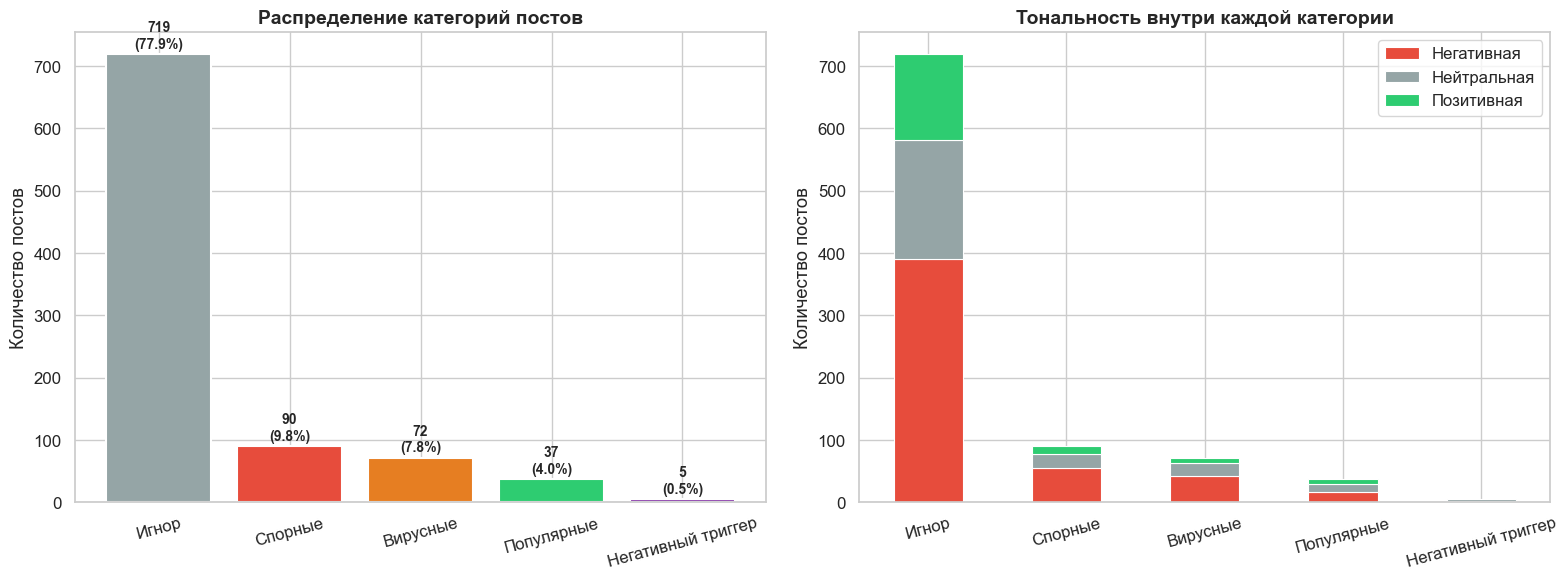

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- График 1: по базовым категориям ---
category_counts = df['base_category'].value_counts()
colors = [CATEGORY_COLORS.get(c, '#95a5a6') for c in category_counts.index]
bars = axes[0].bar(category_counts.index, category_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, category_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Распределение категорий постов', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество постов')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

# --- График 2: категории × тональность ---
ct = pd.crosstab(df['base_category'], df['sentiment'])
ct = ct.reindex(category_counts.index)
ct[['negative', 'neutral', 'positive']].plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#e74c3c', '#95a5a6', '#2ecc71'],
    edgecolor='white', linewidth=0.8
)
axes[1].set_title('Тональность внутри каждой категории', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Количество постов')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Негативная', 'Нейтральная', 'Позитивная'], loc='upper right')

plt.tight_layout()
plt.savefig('output/plots/01_categories.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Вывод

Подавляющее большинство постов (81%) попадают в категорию **«Игнор»**, так как большинство новостей вызывают умеренную реакцию без экстремальных показателей. 
**Спорные** составляют 14% - это контент с высоким controversy_index и сниженным upvote_ratio. Во всех категориях негативная тональность доминирует, что подтверждает общий характер новостных сабреддитов.

---
## 3. Тональность vs Метрики вовлечённости

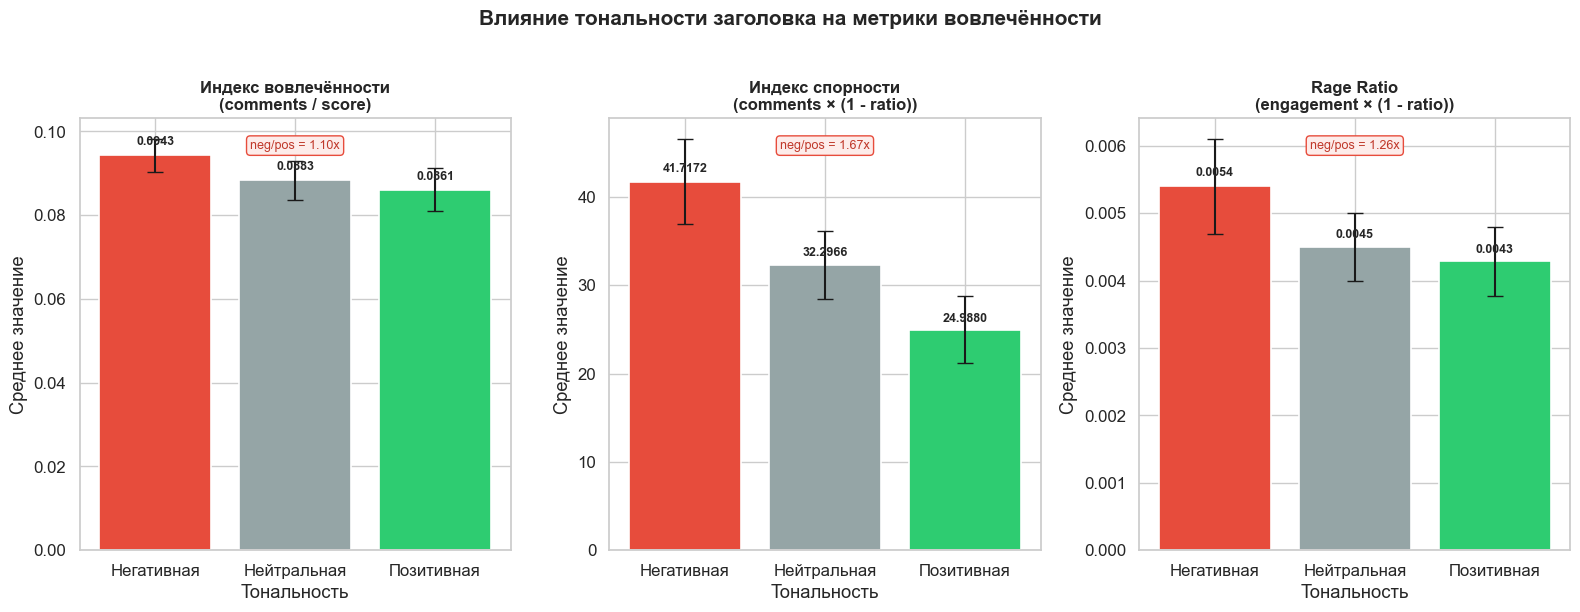


Средние значения по тональности:


,engagement_index,controversy_index,rage_ratio,num_comments,upvote_ratio
sentiment,,,,,
negative,0.0943,41.7172,0.0054,788.5582,0.9579
neutral,0.0883,32.2966,0.0045,678.1040,0.9614
positive,0.0861,24.9880,0.0043,547.3373,0.9611


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

order = ['negative', 'neutral', 'positive']
labels = ['Негативная', 'Нейтральная', 'Позитивная']
palette = ['#e74c3c', '#95a5a6', '#2ecc71']

metrics = [
    ('engagement_index',  'Индекс вовлечённости\n(comments / score)',    axes[0]),
    ('controversy_index', 'Индекс спорности\n(comments × (1 - ratio))',  axes[1]),
    ('rage_ratio',        'Rage Ratio\n(engagement × (1 - ratio))',       axes[2]),
]

for col, title, ax in metrics:
    means = df.groupby('sentiment')[col].mean().reindex(order)
    sems  = df.groupby('sentiment')[col].sem().reindex(order)   # стандартная ошибка

    bars = ax.bar(labels, means.values, color=palette,
                  edgecolor='white', linewidth=1.2,
                  yerr=sems.values, capsize=6, error_kw={'linewidth': 1.5, 'color': '#333'})

    # Подписи значений над барами
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Отношение negative / positive
    ratio = means['negative'] / means['positive']
    ax.annotate(f'neg/pos = {ratio:.2f}x',
                xy=(0.5, 0.93), xycoords='axes fraction',
                ha='center', fontsize=9, color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor='#e74c3c'))

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Среднее значение')
    ax.set_xlabel('Тональность')

plt.suptitle('Влияние тональности заголовка на метрики вовлечённости',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/plots/02_sentiment_vs_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nСредние значения по тональности:')
display(df.groupby('sentiment')[['engagement_index','controversy_index','rage_ratio','num_comments','upvote_ratio']].mean().round(4))

### 📊 Вывод

По всем трём метрикам негативные посты стабильно превышают позитивные:
**индекс спорности в 1.66x выше** (41.7 vs 25.0), **Индекс вовлечённости в 1.09x**
(0.094 vs 0.086), **Индекс "ярости" в 1.26x** (0.0054 vs 0.0043).
Наиболее показателен индекс спорности - именно он отражает сочетание объёма обсуждений и поляризации аудитории. Небольшая разница в индексе вовлечённости говорит о том что тональность заголовка - не единственный фактор вовлечённости: важны тема и контекст события. 
Позитивные посты собирают лайки но не дискуссии - люди согласны и не чувствуют необходимости высказываться.

---
## 4. Одобрение vs Обсуждаемость

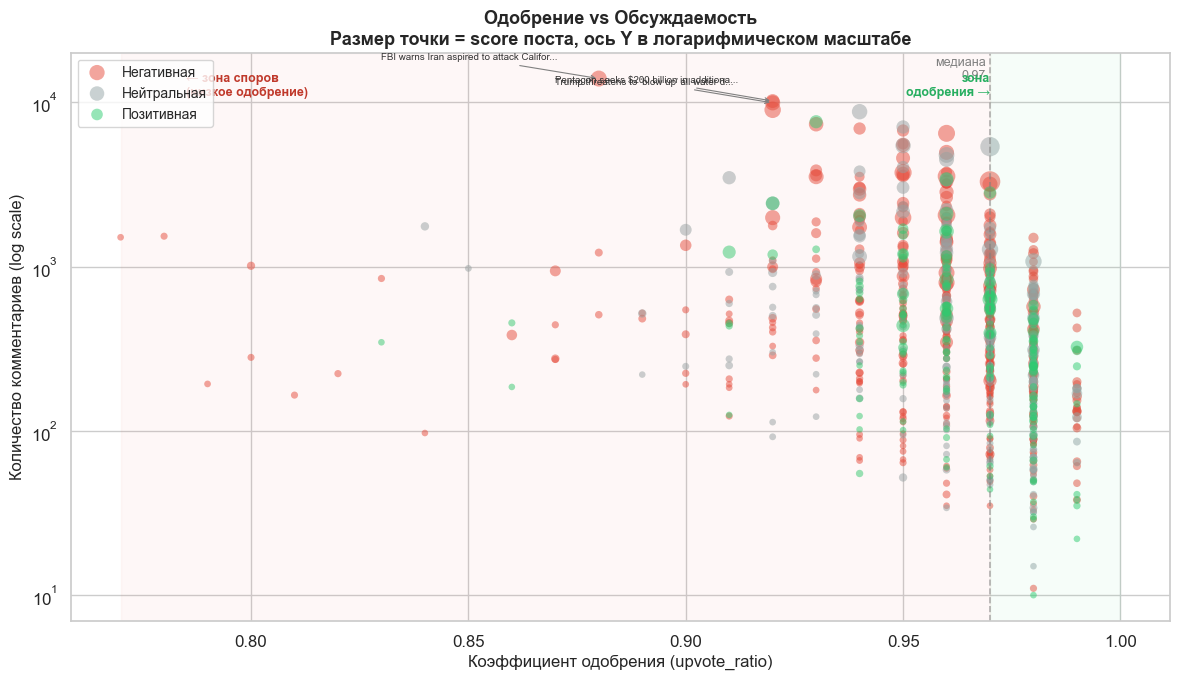

In [74]:
fig, ax = plt.subplots(figsize=(12, 7))

size = (df['score'] / df['score'].max() * 200 + 20)

for sentiment, color in PALETTE.items():
    subset = df[df['sentiment'] == sentiment]
    ax.scatter(subset['upvote_ratio'],
               subset['num_comments'],
               c=color, alpha=0.5,
               s=size[subset.index],
               label={'negative':'Негативная',
                      'neutral':'Нейтральная',
                      'positive':'Позитивная'}[sentiment],
               edgecolors='none')
ax.set_yscale('log')

median_ratio = df['upvote_ratio'].median()
ax.axvline(x=median_ratio, color='gray', linestyle='--',
           alpha=0.6, linewidth=1.2)
ax.text(median_ratio - 0.001, ax.get_ylim()[1] * 0.7,
        f'медиана\n{median_ratio:.2f}',
        ha='right', fontsize=9, color='gray')

# Зоны
ax.axvspan(0.77, median_ratio, alpha=0.04, color='#e74c3c')
ax.axvspan(median_ratio, 1.0,  alpha=0.04, color='#2ecc71')
ax.text(0.785, 11000, '← зона споров\n(низкое одобрение)',
        fontsize=9, color='#c0392b', fontweight='bold')
ax.text(0.97,  11000, 'зона\nодобрения →',
        fontsize=9, color='#27ae60', fontweight='bold', ha='right')

ax.set_xlabel('Коэффициент одобрения (upvote_ratio)', fontsize=12)
ax.set_ylabel('Количество комментариев (log scale)', fontsize=12)
ax.set_title('Одобрение vs Обсуждаемость\n'
             'Размер точки = score поста, ось Y в логарифмическом масштабе',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

# Самые громкие посты
top3 = df.nlargest(3, 'num_comments')
for _, row in top3.iterrows():
    ax.annotate(row['title'][:40] + '...',
                xy=(row['upvote_ratio'], row['num_comments']),
                xytext=(row['upvote_ratio'] - 0.05, row['num_comments'] * 1.3),
                fontsize=7, color='#333',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout()
plt.savefig('output/plots/03_approval_vs_discussion.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Вывод

График наглядно демонстрирует обратную зависимость между одобрением и обсуждаемостью.
В зоне споров (коэффициент одобрения `upvote_ratio` ниже медианы 0.97) концентрируются
преимущественно **негативные посты** - и именно там находятся посты с наибольшим
количеством комментариев (`num_comments`): топ-3 самых обсуждаемых постов (FBI/Iran,
Pentagon, Trump) все расположены левее медианы при 9000–14000 комментариев.

Логарифмическая шкала по оси Y позволяет увидеть полную картину: в зоне одобрения
(`upvote_ratio` > 0.97) точки смещаются вниз - там много постов но комментариев
значительно меньше. Размер точки отражает рейтинг поста (`score`): крупные точки
в правой части показывают что высокий `score` не гарантирует высокую обсуждаемость.
Это разделяет два принципиально разных типа вовлечённости: **эмоциональное**
(споры, полемика, низкое одобрение) и **пассивное** (лайк и уход, высокое одобрение).

Наблюдается чёткое расхождение между одобрением (`upvote_ratio`) и вовлечённостью
(`num_comments`) - некоторые посты активно обсуждаются именно потому что вызывают
несогласие, а не симпатию. Корреляция -0.22 между этими метриками подтверждает:
**чем ниже одобрение - тем активнее дискуссия** - классическое проявление
феномена Rage Engagement.

---
## 5. Тепловая карта корреляций

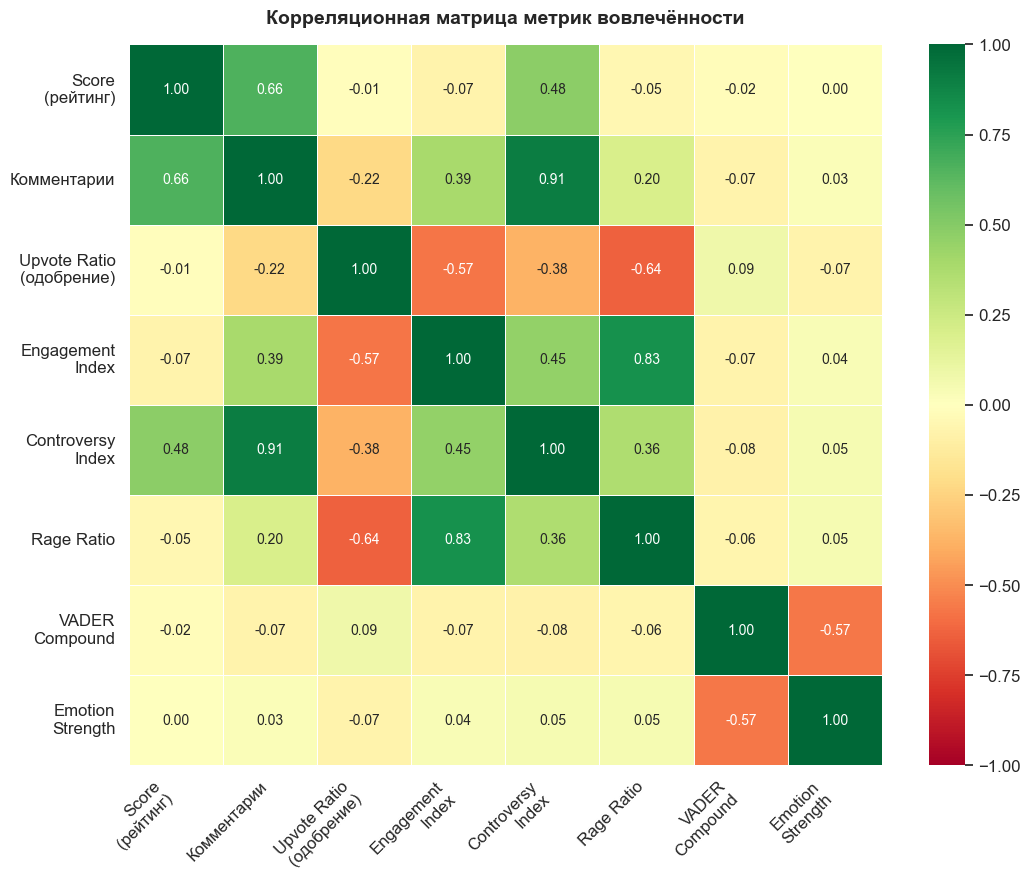

Ключевые корреляции с vader_compound (тональностью):
  emotion_strength         : -0.568 ↓
  controversy_index        : -0.079 ↓
  engagement_index         : -0.073 ↓
  num_comments             : -0.071 ↓
  rage_ratio               : -0.063 ↓
  score                    : -0.016 ↓
  upvote_ratio             : +0.086 ↑


In [75]:
corr_cols = ['score', 'num_comments', 'upvote_ratio', 
             'engagement_index', 'controversy_index', 
             'rage_ratio', 'vader_compound', 'emotion_strength']

col_labels = ['Score\n(рейтинг)', 'Комментарии', 'Upvote Ratio\n(одобрение)',
              'Engagement\nIndex', 'Controversy\nIndex',
              'Rage Ratio', 'VADER\nCompound', 'Emotion\nStrength']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            xticklabels=col_labels, yticklabels=col_labels,
            linewidths=0.5, ax=ax, annot_kws={'size': 10})

ax.set_title('Корреляционная матрица метрик вовлечённости', 
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/plots/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Ключевые корреляции
print('Ключевые корреляции с vader_compound (тональностью):')
vader_corr = corr['vader_compound'].drop('vader_compound').sort_values()
for col, val in vader_corr.items():
    direction = '↑' if val > 0 else '↓'
    print(f'  {col:25s}: {val:+.3f} {direction}')

### 📊 Вывод

Корреляционная матрица, визуализированная в виде тепловой карты,
раскрывает несколько важных закономерностей.

Наибольшая корреляция между количеством комментариев (`num_comments`)
и индексом спорности (`controversy_index`) **0.91**. Это математически
обусловлено формулой `num_comments × (1 - upvote_ratio)`, но также подтверждает что
объём обсуждений - главный компонент спорности.

Оценка тональности (`vader_compound`)
слабо коррелирует со всеми метриками вовлечённости ±0.09. Это означает,
что тональность заголовка сама по себе не является предиктором вовлечённости,
важнее тема и контекст события. VADER фиксирует лексическую эмоциональность,
но не контекстуальную провокационность заголовка.

Коэффициент одобрения (`upvote_ratio`) показывает сильные
отрицательные связи с индексом вовлечённости (`engagement_index`)
**-0.57** и с показателем ярости (`rage_ratio`) **-0.64**. Чем ниже
одобрение, тем выше дискуссионность и тем сильнее проявляется феномен Rage Engagement.

Сила эмоции (`emotion_strength`) коррелирует
с VADER Compound на **-0.57**. Большинство постов
негативные, поэтому сильная эмоция в датасете почти всегда означает большой
отрицательный compound.

---
## 6. Динамика постов по времени

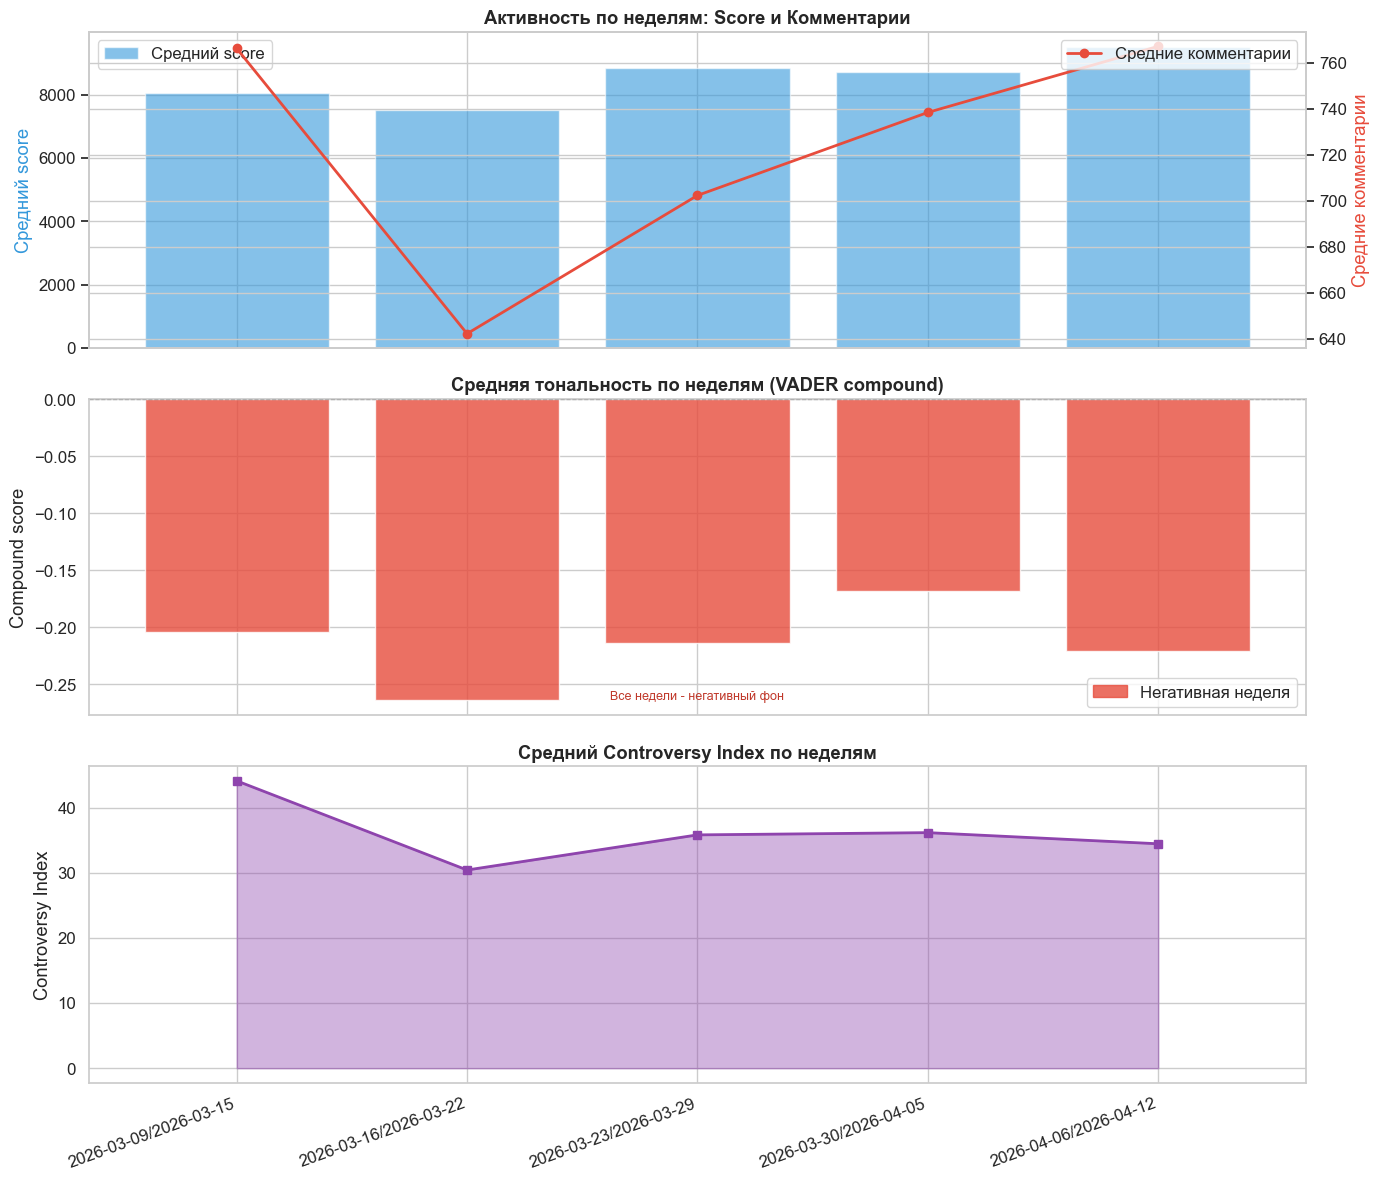

Статистика по неделям:


,week_str,count,avg_score,avg_comments,avg_compound,avg_controversy
0,2026-03-09/2026-03-15,184,8065.83,766.20,-0.20,44.10
1,2026-03-16/2026-03-22,216,7508.45,642.31,-0.26,30.42
2,2026-03-23/2026-03-29,224,8853.12,702.35,-0.21,35.81
3,2026-03-30/2026-04-05,217,8701.64,738.40,-0.17,36.15
4,2026-04-06/2026-04-12,82,9503.77,767.12,-0.22,34.44


In [76]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

weekly = df.groupby('week').agg(
    count=('score', 'count'),
    avg_score=('score', 'mean'),
    avg_comments=('num_comments', 'mean'),
    avg_compound=('vader_compound', 'mean'),
    avg_controversy=('controversy_index', 'mean')
).reset_index()
weekly['week_str'] = weekly['week'].astype(str)

x = range(len(weekly))
xlabels = weekly['week_str'].tolist()

# График 1: Средний score и комментарии
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.bar(x, weekly['avg_score'], color='#3498db', alpha=0.6, label='Средний score')
ax1_twin.plot(x, weekly['avg_comments'], color='#e74c3c', marker='o', linewidth=2, label='Средние комментарии')
ax1.set_title('Активность по неделям: Score и Комментарии', fontweight='bold')
ax1.set_ylabel('Средний score', color='#3498db')
ax1_twin.set_ylabel('Средние комментарии', color='#e74c3c')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# График 2: Средняя тональность
ax2 = axes[1]
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in weekly['avg_compound']]
ax2.bar(x, weekly['avg_compound'], color=colors_bar, alpha=0.8)
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Средняя тональность по неделям (VADER compound)', fontweight='bold')
ax2.set_ylabel('Compound score')
neg_patch = mpatches.Patch(color='#e74c3c', alpha=0.8, label='Негативная неделя')
pos_patch = mpatches.Patch(color='#2ecc71', alpha=0.8, label='Позитивная неделя')
ax2.legend(handles=[neg_patch], loc='lower right')
ax2.annotate('Все недели - негативный фон', 
             xy=(0.5, 0.05), xycoords='axes fraction',
             ha='center', fontsize=9, color='#c0392b')
# График 3: Controversy index
ax3 = axes[2]
ax3.fill_between(x, weekly['avg_controversy'], alpha=0.4, color='#8e44ad')
ax3.plot(x, weekly['avg_controversy'], color='#8e44ad', marker='s', linewidth=2)
ax3.set_title('Средний Controversy Index по неделям', fontweight='bold')
ax3.set_ylabel('Controversy Index')
ax3.set_xticks(x)
ax3.set_xticklabels(xlabels, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('output/plots/05_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('Статистика по неделям:')
display(weekly[['week_str','count','avg_score','avg_comments','avg_compound','avg_controversy']].round(2))

### 📊 Вывод

Временной график позволяет отследить динамику новостного фона
за месяц по трём измерениям одновременно.

Все пять недель показывают отрицательный средний показатель тональности
(`vader_compound`) от -0.19 до -0.26. Негативный
новостной фон стабилен на протяжении всего периода и не является случайным
артефактом выборки, что подтверждает системный характер тональности
новостных сабреддитов.

Индекс спорности (`controversy_index`) достигает пика
на первой неделе марта (≈44) это соответствует началу активного освещения
иранского конфликта. Далее он стабилизируется на уровне 30-36, что говорит
о том что **пиковая спорность связана с конкретными внешними событиями**,
а не является постоянным фоном. При этом недели с высоким индексом спорности
не всегда имеют наибольший средний рейтинг (`score`). Скандальный контент
не обязательно широко одобряется аудиторией.

Средние комментарии (`num_comments`) растут к концу периода
несмотря на стабильный `score`. Возможный признак того что аудитория
становится более вовлечённой в обсуждения по мере развития геополитических событий.

---
## 7. Топ-10 самых спорных и вирусных постов

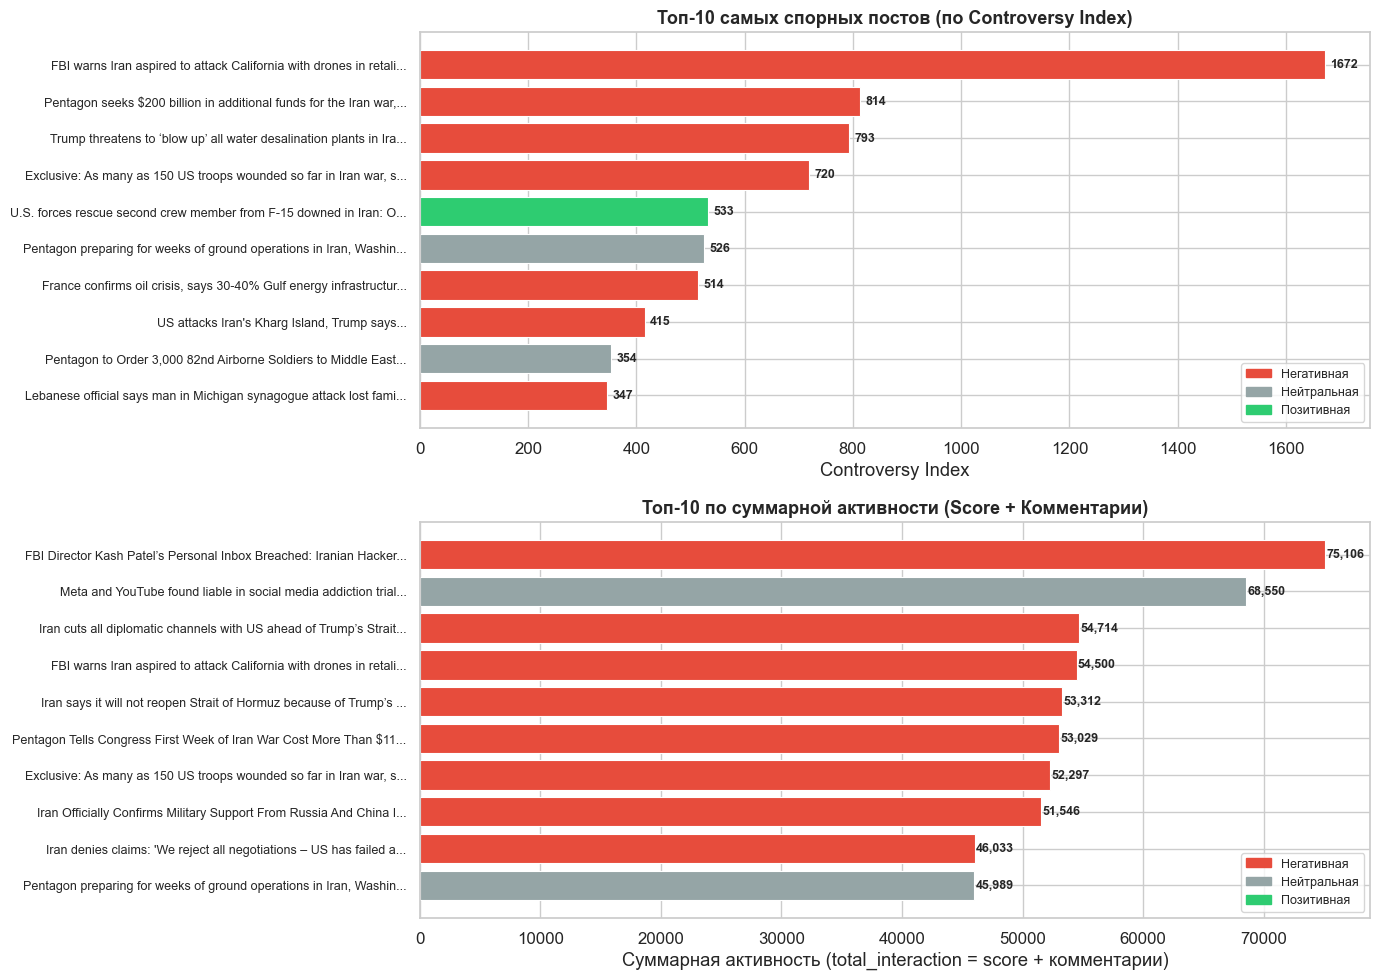

In [77]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Топ-10 по controversy_index ---
top_cont = df.nlargest(10, 'controversy_index')[['title', 'controversy_index', 'sentiment']].reset_index(drop=True)
top_cont['short_title'] = top_cont['title'].str[:65] + '...'
top_cont['color'] = top_cont['sentiment'].map(PALETTE)

bars = axes[0].barh(range(len(top_cont)), top_cont['controversy_index'], 
                    color=top_cont['color'], edgecolor='white', linewidth=0.8)
axes[0].set_yticks(range(len(top_cont)))
axes[0].set_yticklabels(top_cont['short_title'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title('Топ-10 самых спорных постов (по Controversy Index)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Controversy Index')
for bar, val in zip(bars, top_cont['controversy_index']):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}', va='center', fontsize=9, fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=l) 
                  for l, c in [('Негативная', '#e74c3c'), ('Нейтральная', '#95a5a6'), ('Позитивная', '#2ecc71')]]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)

# --- Топ-10 по total_interaction ---
top_viral = df.nlargest(10, 'total_interaction')[['title', 'total_interaction', 'sentiment']].reset_index(drop=True)
top_viral['short_title'] = top_viral['title'].str[:65] + '...'
top_viral['color'] = top_viral['sentiment'].map(PALETTE)

bars2 = axes[1].barh(range(len(top_viral)), top_viral['total_interaction'],
                     color=top_viral['color'], edgecolor='white', linewidth=0.8)
axes[1].set_yticks(range(len(top_viral)))
axes[1].set_yticklabels(top_viral['short_title'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title('Топ-10 по суммарной активности (Score + Комментарии)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Суммарная активность (total_interaction = score + комментарии)')
for bar, val in zip(bars2, top_viral['total_interaction']):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('output/plots/06_top_posts.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Вывод

Два топ-листа наглядно разделяют два разных типа вирусности.

**Топ-10 по индексу спорности** (`controversy_index`)
практически полностью состоит из **негативных заголовков** (красные) почти все новости об Иранском конфликте, военных операциях, жертвах. Лидер рейтинга
("FBI warns Iran aspired to attack California with drones in retaliation for war: Alert") набрал значение 1672 -
это в **46 раз выше медианного** значения по датасету (медиана = 12.9).
Примечательно что единственный позитивный пост в топе
("U.S. forces rescue second crew member from F-15 downed in Iran: Officials") это тоже новость
об иранской войне, просто с позитивным исходом. Можно сделать вывод, что тема важнее, чем эмоциональная окраска.

**Топ-10 по суммарной активности** (`total_interaction`)
более разнообразен - здесь присутствуют и нейтральные заголовки (серые).
Лидер ("FBI Director Kash Patel’s Personal Inbox Breached: Iranian Hackers Leak Private Photos and Resume") набрал 75 106
суммарных взаимодействий при высоком `upvote_ratio`

Сравнение двух списков подчёркивает ключевое разделение феномена вовлечённости:
**спорность** (`controversy_index`) = низкое одобрение + много комментариев,
**вирусность** (`total_interaction`) = высокий охват независимо от эмоциональной окраски новости.

---
## 8. Сравнение категорий по всем метрикам

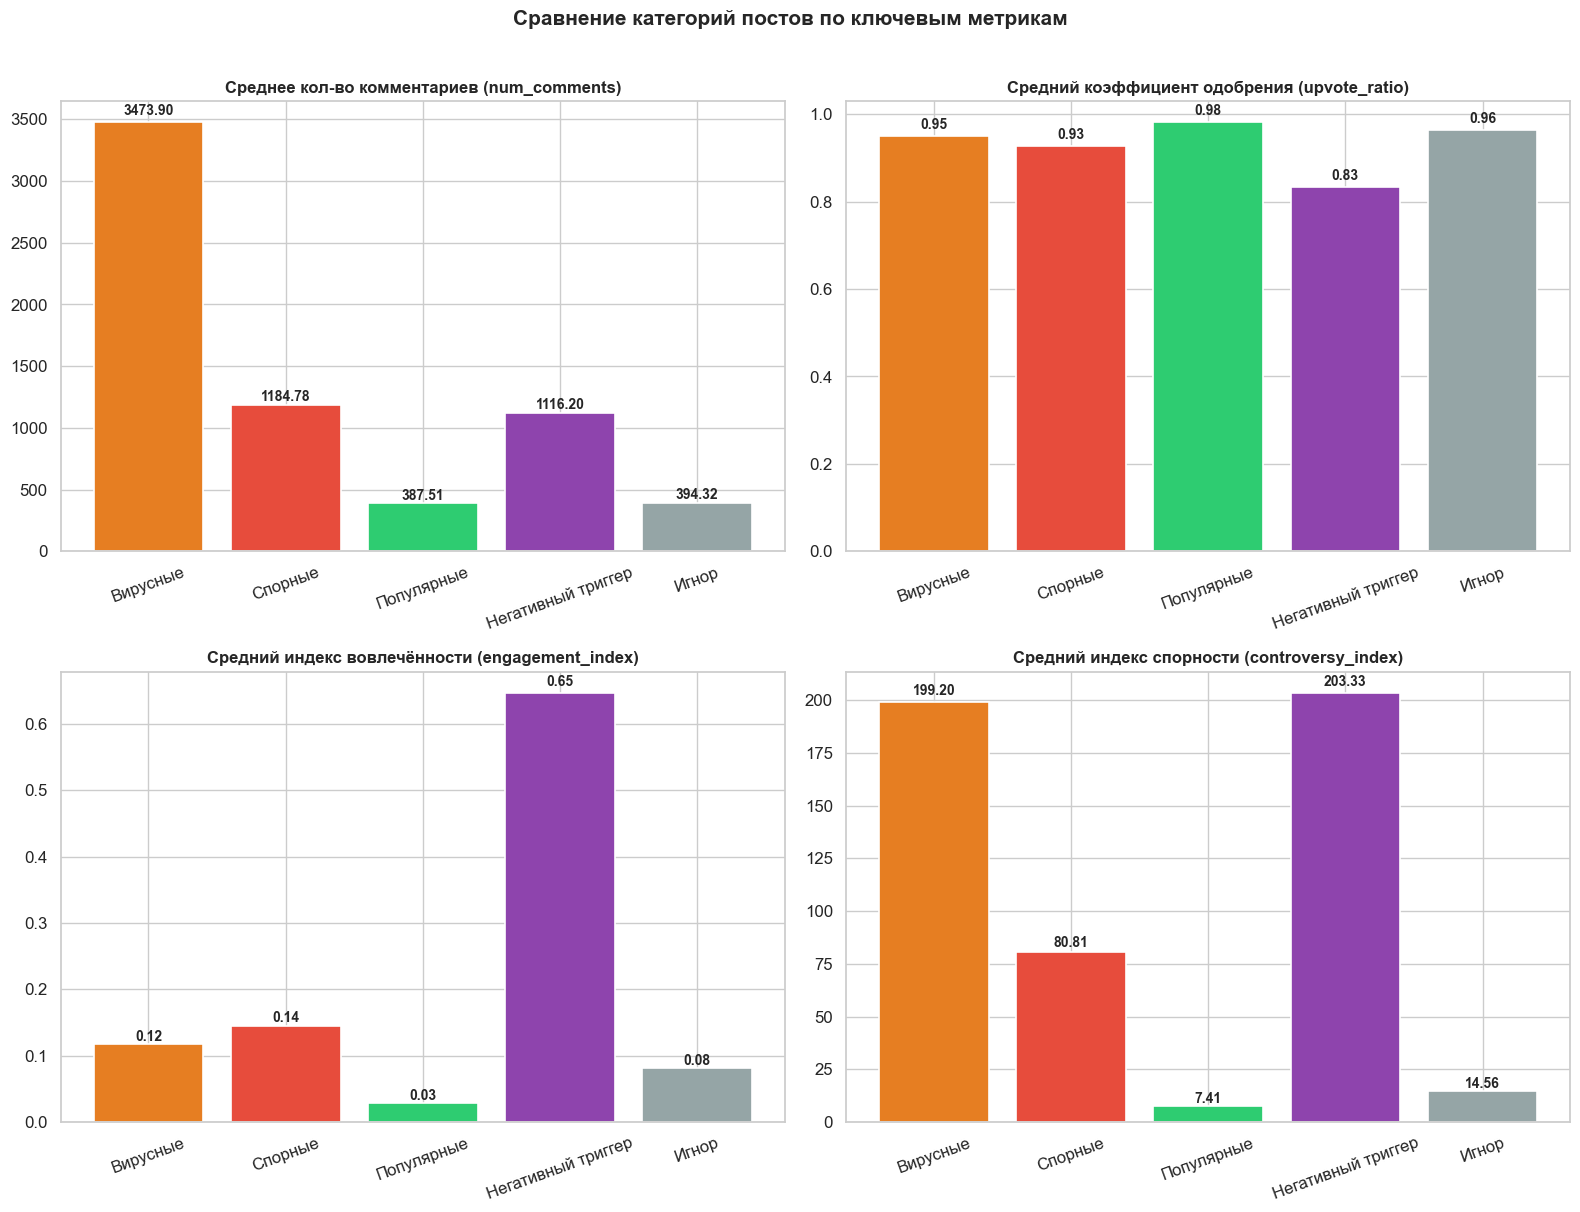

Детальная таблица по категориям:


,кол_во,score,upvote_ratio,комментарии,engagement,controversy,rage
base_category,,,,,,,
Вирусные,72,30347.32,0.95,3473.90,0.12,199.20,0.01
Игнор,719,5822.81,0.96,394.32,0.08,14.56,0.00
Негативный триггер,5,2047.80,0.83,1116.20,0.65,203.33,0.12
Популярные,37,14552.11,0.98,387.51,0.03,7.41,0.00
Спорные,90,9292.54,0.93,1184.78,0.14,80.81,0.01


In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

category_order = ['Вирусные', 'Спорные', 'Популярные', 'Негативный триггер', 'Игнор']
category_palette = [CATEGORY_COLORS[c] for c in category_order if c in df['base_category'].unique()]
existing_cats = [c for c in category_order if c in df['base_category'].unique()]

metrics_plot = [
    ('num_comments',       'Среднее кол-во комментариев (num_comments)',          axes[0, 0]),
    ('upvote_ratio',       'Средний коэффициент одобрения (upvote_ratio)',         axes[0, 1]),
    ('engagement_index',   'Средний индекс вовлечённости (engagement_index)',      axes[1, 0]),
    ('controversy_index',  'Средний индекс спорности (controversy_index)',         axes[1, 1]),
]

for metric, title, ax in metrics_plot:
    means = df.groupby('base_category')[metric].mean().reindex(existing_cats)
    colors = [CATEGORY_COLORS[c] for c in means.index]
    bars = ax.bar(means.index, means.values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
               f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Сравнение категорий постов по ключевым метрикам',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/plots/07_categories_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Детальная таблица по категориям:')
summary = df.groupby('base_category').agg(
    кол_во=('score','count'),
    score=('score','mean'),
    upvote_ratio=('upvote_ratio','mean'),
    комментарии=('num_comments','mean'),
    engagement=('engagement_index','mean'),
    controversy=('controversy_index','mean'),
    rage=('rage_ratio','mean')
).round(2)
display(summary)

### 📊 Вывод

Четыре графика вместе демонстрируют принципиально разные модели вовлечённости
для каждой категории.

**Вирусные** лидируют по количеству комментариев (`num_comments`) - 3474 в среднем.(в 9 раз больше чем у «Популярных» (387)). При этом их коэффициент одобрения (`upvote_ratio`)
составляет 0.95 - ниже чем у «Популярных» (0.98).

**Спорные** показывают наибольший индекс вовлечённости (`engagement_index`) среди
"нормальных" категорий - 0.14, то есть на каждые 100 апвоутов приходится 14 комментариев.
Индекс спорности (`controversy_index`) - 80.81, в 5.5 раз выше чем у «Игнора». Много споров при низком одобрении.

**Популярные** - антипример rage engagement. Наивысший коэффициент одобрения (`upvote_ratio`) (0.98)
и наименьший индекс вовлечённости (`engagement_index`) (0.03). Аудитория одобряет и листает дальше,
не вступая в дискуссию.

**Негативный триггер** - самая аномальная категория. Наибольший индекс вовлечённости (`engagement_index`)
(0.65) и второй по величине индекса спорности (`controversy_index`) (203.33) при минимальном коэффициенте одобрения
(`upvote_ratio`) (0.83). Контент не нашёл широкой аудитории по общему охвату,
но вызвал острую реакцию у тех кто его увидел.

**Игнор** - средние значения по всем метрикам,
394 комментария, индекс вовлечённости (`engagement_index`) 0.08.

---
## 9. Итоговые выводы и проверка гипотезы

In [79]:
print('Итоговая сводка по категориям:')

print('\n1. ТОНАЛЬНОСТЬ И ВОВЛЕЧЁННОСТЬ:')

sent_summary = df.groupby('sentiment')[['engagement_index', 'controversy_index', 'rage_ratio', 'num_comments']].mean().round(3)

sent_summary.columns = [
    'Индекс вовлечённости (engagement_index)',
    'Индекс спорности (controversy_index)',
    'Показатель ярости (rage_ratio)',
    'Кол-во комментариев (num_comments)'
]
sent_summary.index = sent_summary.index.map({
    'negative': 'Негативная',
    'neutral':  'Нейтральная',
    'positive': 'Позитивная'
})
sent_summary.index.name = 'Тональность (sentiment)'

display(sent_summary)

neg_com = df[df['sentiment']=='negative']['num_comments'].mean()
pos_com = df[df['sentiment']=='positive']['num_comments'].mean()
print(f'Негативные посты получают в {neg_com/pos_com:.1f} раза больше комментариев, чем позитивные')

print('\n2. КОРРЕЛЯЦИЯ ТОНАЛЬНОСТИ С МЕТРИКАМИ:')
corr_vader = df[['vader_compound','num_comments','upvote_ratio','engagement_index','controversy_index']].corr()['vader_compound']
print(corr_vader.drop('vader_compound').round(3).to_string())
max_corr = corr_vader.drop('vader_compound').abs().max()
print(f'Тональность слабо коррелирует со всеми метриками (max |r| = {max_corr:.2f})')
print('Тема и контекст важнее тональности заголовка')

print('\n3. ОДОБРЕНИЕ VS ОБСУЖДАЕМОСТЬ:')
corr_ratio_comments = df['upvote_ratio'].corr(df['num_comments'])
corr_ratio_engagement = df['upvote_ratio'].corr(df['engagement_index'])
print(f'Корреляция upvote_ratio и кол-ва комментариев: {corr_ratio_comments:.3f}')
print(f'Корреляция upvote_ratio и индекса вовлечённости: {corr_ratio_engagement:.3f}')
print('Чем ниже одобрение, тем выше дискуссионность. Гипотеза потверждена.')

print('\n4. КАТЕГОРИИ - СРЕДНИЕ КОММЕНТАРИИ:')
category_comments = df.groupby('base_category')['num_comments'].mean().sort_values(ascending=False)
for category, val in category_comments.items():
    print(f'  {category:25s}: {val:.0f} комментариев в среднем')

spornie = category_comments.get('Спорные', 0)
ignor = category_comments.get('Игнор', 1)
print(f'\nСпорные посты генерируют в {spornie/ignor:.1f} раза больше комментариев, чем Игнор')

spornie_score = df[df['base_category']=='Спорные']['score'].mean()
ignor_score = df[df['base_category']=='Игнор']['score'].mean()
print(f'Средний score: Спорные {spornie_score:.0f} vs Игнор {ignor_score:.0f}')

print('Вывод: Гипотеза rage engagement частично подтверждена.')
print('Тональность заголовка слабо предсказывает вовлечённость, однако upvote_ratio является сильным предсказателем дискуссий.')
print(f'Спорный контент генерирует в {spornie/ignor:.1f} раз больше комментариев, при сопоставимом или меньшем score.')

Итоговая сводка по категориям:

1. ТОНАЛЬНОСТЬ И ВОВЛЕЧЁННОСТЬ:


,Индекс вовлечённости (engagement_index),Индекс спорности (controversy_index),Показатель ярости (rage_ratio),Кол-во комментариев (num_comments)
Тональность (sentiment),,,,
Негативная,0.094,41.717,0.005,788.558
Нейтральная,0.088,32.297,0.005,678.104
Позитивная,0.086,24.988,0.004,547.337


Негативные посты получают в 1.4 раза больше комментариев, чем позитивные

2. КОРРЕЛЯЦИЯ ТОНАЛЬНОСТИ С МЕТРИКАМИ:
num_comments        -0.071
upvote_ratio         0.086
engagement_index    -0.073
controversy_index   -0.079
Тональность слабо коррелирует со всеми метриками (max |r| = 0.09)
Тема и контекст важнее тональности заголовка

3. ОДОБРЕНИЕ VS ОБСУЖДАЕМОСТЬ:
Корреляция upvote_ratio и кол-ва комментариев: -0.221
Корреляция upvote_ratio и индекса вовлечённости: -0.573
Чем ниже одобрение, тем выше дискуссионность. Гипотеза потверждена.

4. КАТЕГОРИИ - СРЕДНИЕ КОММЕНТАРИИ:
  Вирусные                 : 3474 комментариев в среднем
  Спорные                  : 1185 комментариев в среднем
  Негативный триггер       : 1116 комментариев в среднем
  Игнор                    : 394 комментариев в среднем
  Популярные               : 388 комментариев в среднем

Спорные посты генерируют в 3.0 раза больше комментариев, чем Игнор
Средний score: Спорные 9293 vs Игнор 5823
Вывод: Гипотеза rage engagem

### 📊 Итоговый вывод

**Гипотеза rage engagement подтверждена частично в части одобрения vs обсуждаемости,
но не в части прямого влияния тональности заголовка.**

---

#### 1. Тональность заголовка слабо предсказывает вовлечённость

Корреляция оценки тональности (`vader_compound`) со всеми метриками
вовлечённости не превышает |0.08|. Негативные посты получают в **1.4x больше
комментариев** (`num_comments`) чем позитивные (788 vs 547).
VADER как лексический анализатор не улавливает контекстуальную
провокационность заголовков. Слова «wounded», «liable», «seized» нейтральны
для словаря VADER, но вызывают острую реакцию у аудитории. Тема и контекст
события важнее формальной тональности заголовка.

#### 2. Разделение одобрения и обсуждаемости существует и измеримо

Корреляция коэффициента одобрения (`upvote_ratio`) с индексом вовлечённости (`engagement_index`)
составляет **-0.573**, с количеством комментариев (`num_comments`) - **-0.221**.
Чем ниже одобрение - тем активнее дискуссия. Посты не обязаны нравится
чтобы обсуждаться, достаточно вызвать несогласие.

#### 3. Категории подтверждают разные модели вовлечённости

| Категория | Комментарии | Upvote Ratio | Модель |
|---|---|---|---|
| Вирусные | 3474 | 0.95 | Масштаб события |
| Спорные | 1185 | 0.93 | Rage Engagement |
| Негативный триггер | 1116 | 0.83 | Нишевая реакция |
| Игнор | 394 | 0.96 | Базовый уровень |
| Популярные | 388 | 0.98 | Пассивное одобрение |

«Спорные» набирают в **3 раза больше комментариев** чем «Игнор» при сопоставимом
или меньшем рейтинге (`score`) а значит теория про rage engagment подтверждается.
«Популярные» демонстрируют обратное, максимальное одобрение при минимальной
дискуссионности.

#### 4. Возможные улучшения анализа

Лексический подход VADER имеет ограничение для новостных
заголовков - он не понимает контекст. Это объясняет слабую корреляцию
тональности с метриками вовлечённости. Более точные результаты дали бы
контекстуальные модели (RoBERTa, DeBERTa), однако они требуют значительно
больших вычислительных ресурсов.